<a href="https://colab.research.google.com/github/priyansh-commits/email-spam-classifier/blob/main/email_spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install -q "kagglehub[pandas-datasets]"

import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/sms-spam-collection-dataset",
    "spam.csv",
    pandas_kwargs={
        "encoding": "latin-1"
    }
)

print(df.head())
print(df.shape)

/tmp/ipykernel_659/1571271682.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
(5572, 5)


DATA ANALYSIS


In [28]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [30]:
df=df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [31]:
df.sample(5)

,v1,v2
603,ham,Be happy there. I will come after noon
2315,ham,That's significant but dont worry.
5016,spam,Dear 0776xxxxxxx U've been invited to XCHAT. T...
3335,ham,Then u go back urself lor...
2779,ham,Well I might not come then...


In [32]:
df.shape

(5572, 2)

In [33]:
df.isnull().sum()

,0
v1,0
v2,0


In [34]:
df.duplicated().sum()

np.int64(403)

In [35]:
df = df.drop_duplicates(keep='first')

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df['v1'])
df['v1'] = le.transform(df['v1'])

print(le.classes_)

['ham' 'spam']


ham(not spam) is encoded to 0 and spam is encoded to 1

In [38]:
df['v1'].value_counts()

,count
v1,
0,4516
1,653


DATA VISUALIZATION and TOKENIZATION



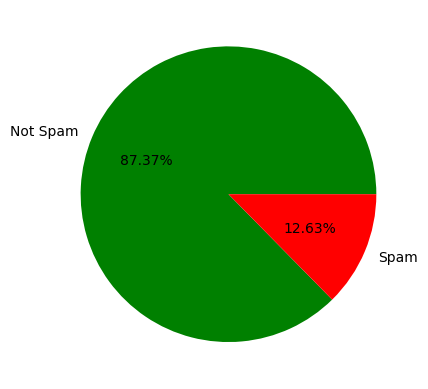

In [42]:
import matplotlib.pyplot as plt
plt.pie(df['v1'].value_counts(), labels=['Not Spam','Spam'], autopct="%.2f%%", colors=['green','red'])
plt.show()

In [48]:
import nltk
!pip install nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [69]:
# Tokenization using NLTK


df['char']=df['v2'].apply(lambda x: len(x))
df['num_digits'] = df['v2'].apply(
    lambda x: sum(c.isdigit() for c in x)
)
df['num_special_chars'] = df['v2'].apply(
    lambda x: sum(not c.isalnum() and not c.isspace() for c in x)
)
df['num_words']=df['v2'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sent']=df['v2'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [61]:
df.drop(columns=['words','sent'])

,v1,v2,num_words,num_sent,char
0,0,"Go until jurong point, crazy.. Available only ...",24,2,111
1,0,Ok lar... Joking wif u oni...,8,2,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2,155
3,0,U dun say so early hor... U c already then say...,13,1,49
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1,61
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,35,4,161
5568,0,Will Ì_ b going to esplanade fr home?,9,1,37
5569,0,"Pity, * was in mood for that. So...any other s...",15,2,57
5570,0,The guy did some bitching but I acted like i'd...,27,1,125


In [70]:
df[['num_words',	'num_sent'	,'char','num_special_chars','num_digits']].describe()

,num_words,num_sent,char,num_special_chars,num_digits
count,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000
mean,18.455794,1.965564,78.977945,4.165603,2.205069
std,13.324758,1.448541,58.236293,4.477762,6.025241
min,1.000000,1.000000,2.000000,0.000000,0.000000
25%,9.000000,1.000000,36.000000,2.000000,0.000000
50%,15.000000,1.000000,60.000000,3.000000,0.000000
75%,26.000000,2.000000,117.000000,6.000000,1.000000
max,220.000000,38.000000,910.000000,133.000000,47.000000


In [71]:
df[df['v1']==0][['num_words',	'num_sent'	,'char','num_special_chars','num_digits']].describe()

,num_words,num_sent,char,num_special_chars,num_digits
count,4516.000000,4516.000000,4516.000000,4516.000000,4516.000000
mean,17.123782,1.820195,70.459256,3.891275,0.290301
std,13.493970,1.383657,56.358207,4.531656,1.011825
min,1.000000,1.000000,2.000000,0.000000,0.000000
25%,8.000000,1.000000,34.000000,1.000000,0.000000
50%,13.000000,1.000000,52.000000,3.000000,0.000000
75%,22.000000,2.000000,90.000000,5.000000,0.000000
max,220.000000,38.000000,910.000000,133.000000,23.000000


In [72]:
df[df['v1']==1][['num_words',	'num_sent'	,'char','num_special_chars','num_digits']].describe()

,num_words,num_sent,char,num_special_chars,num_digits
count,653.000000,653.000000,653.000000,653.000000,653.000000
mean,27.667688,2.970904,137.891271,6.062787,15.447167
std,7.008418,1.488425,30.137753,3.548616,8.924653
min,2.000000,1.000000,13.000000,0.000000,0.000000
25%,25.000000,2.000000,132.000000,3.000000,9.000000
50%,29.000000,3.000000,149.000000,6.000000,16.000000
75%,32.000000,4.000000,157.000000,8.000000,22.000000
max,46.000000,9.000000,224.000000,26.000000,47.000000


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

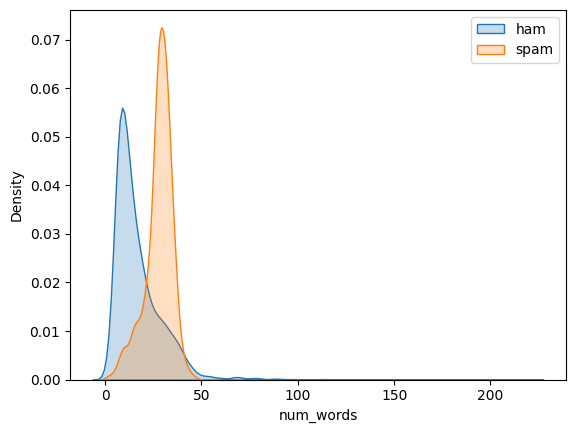

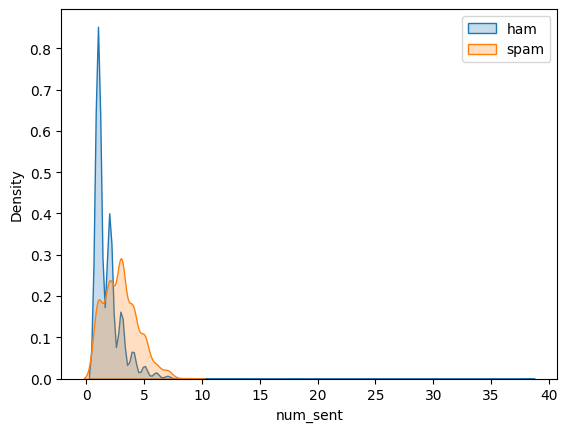

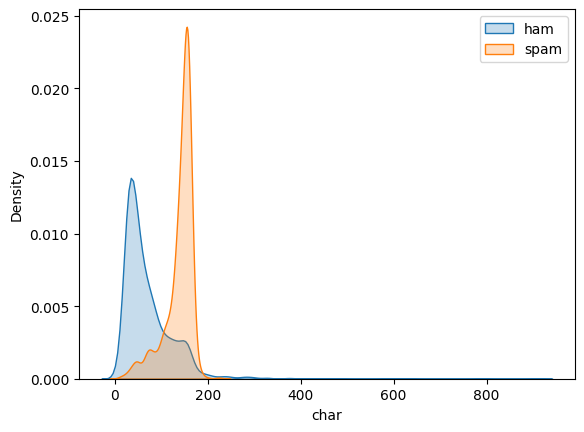

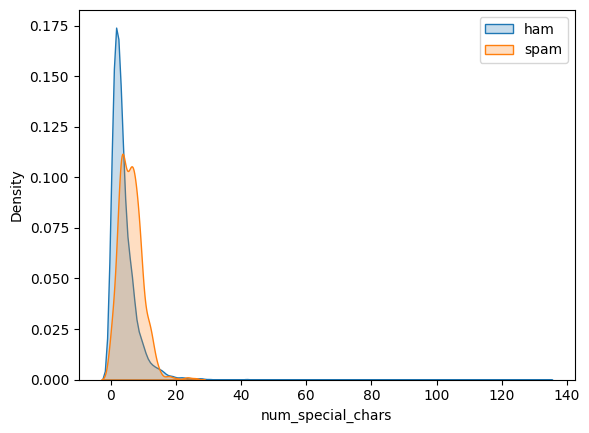

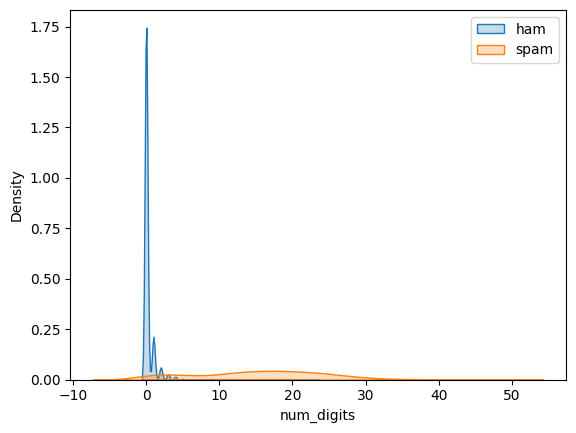

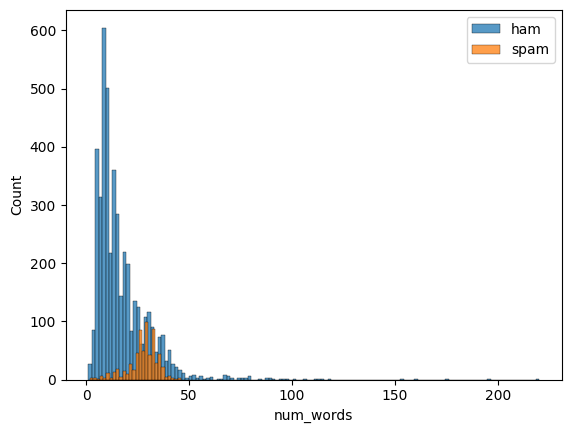

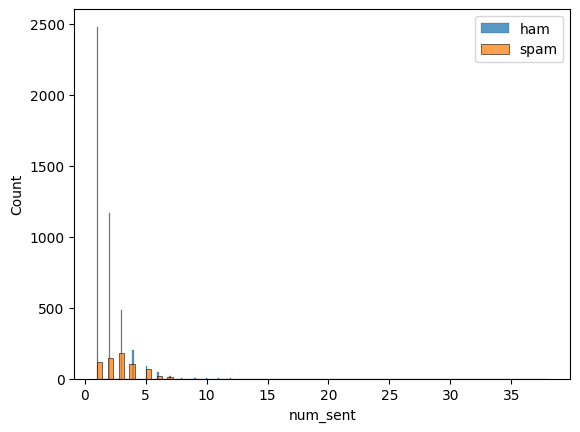

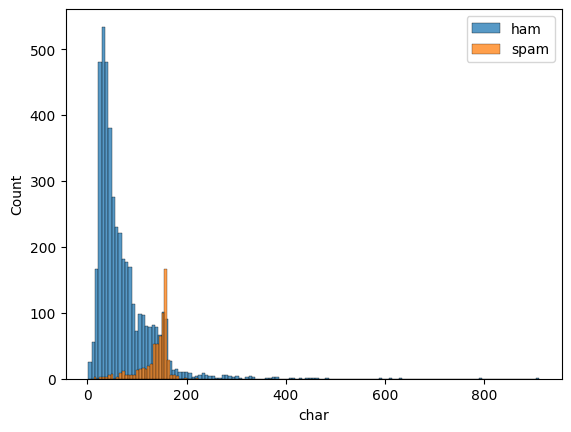

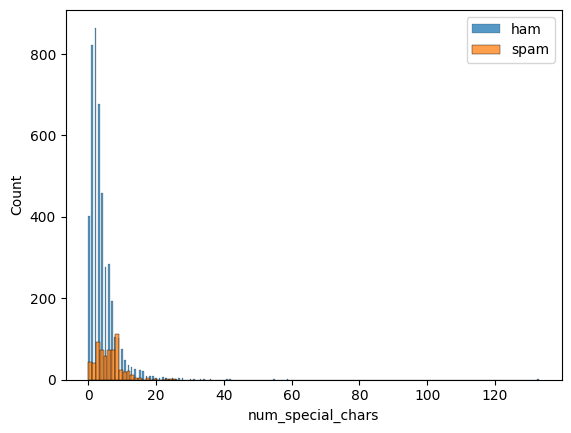

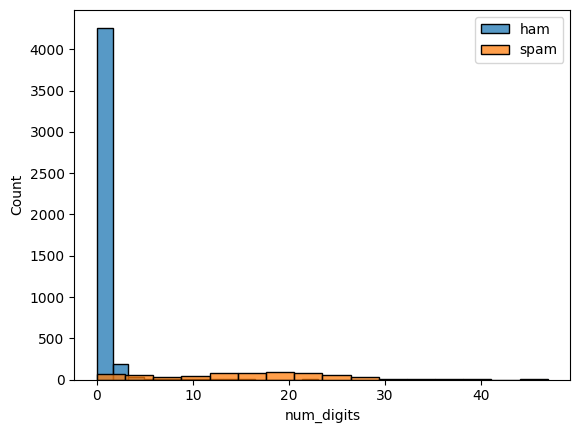

In [73]:
for i in ['num_words',	'num_sent'	,'char','num_special_chars','num_digits']:
  sns.kdeplot(df[df['v1']==0][i],label='ham',fill=True)
  sns.kdeplot(df[df['v1']==1][i],label='spam',fill=True)

  plt.legend()
  plt.show()
for i in ['num_words',	'num_sent'	,'char','num_special_chars','num_digits']:

  sns.histplot(df[df['v1']==0][i],label='ham',fill=True)
  sns.histplot(df[df['v1']==1][i],label='spam',fill=True)
  plt.legend()
  plt.show()

NUMBER OF WORDS,SENTENCE,DIGITS AND CHARACTERS ARE GREATER IN SPAM AS COMPARED TO HAM

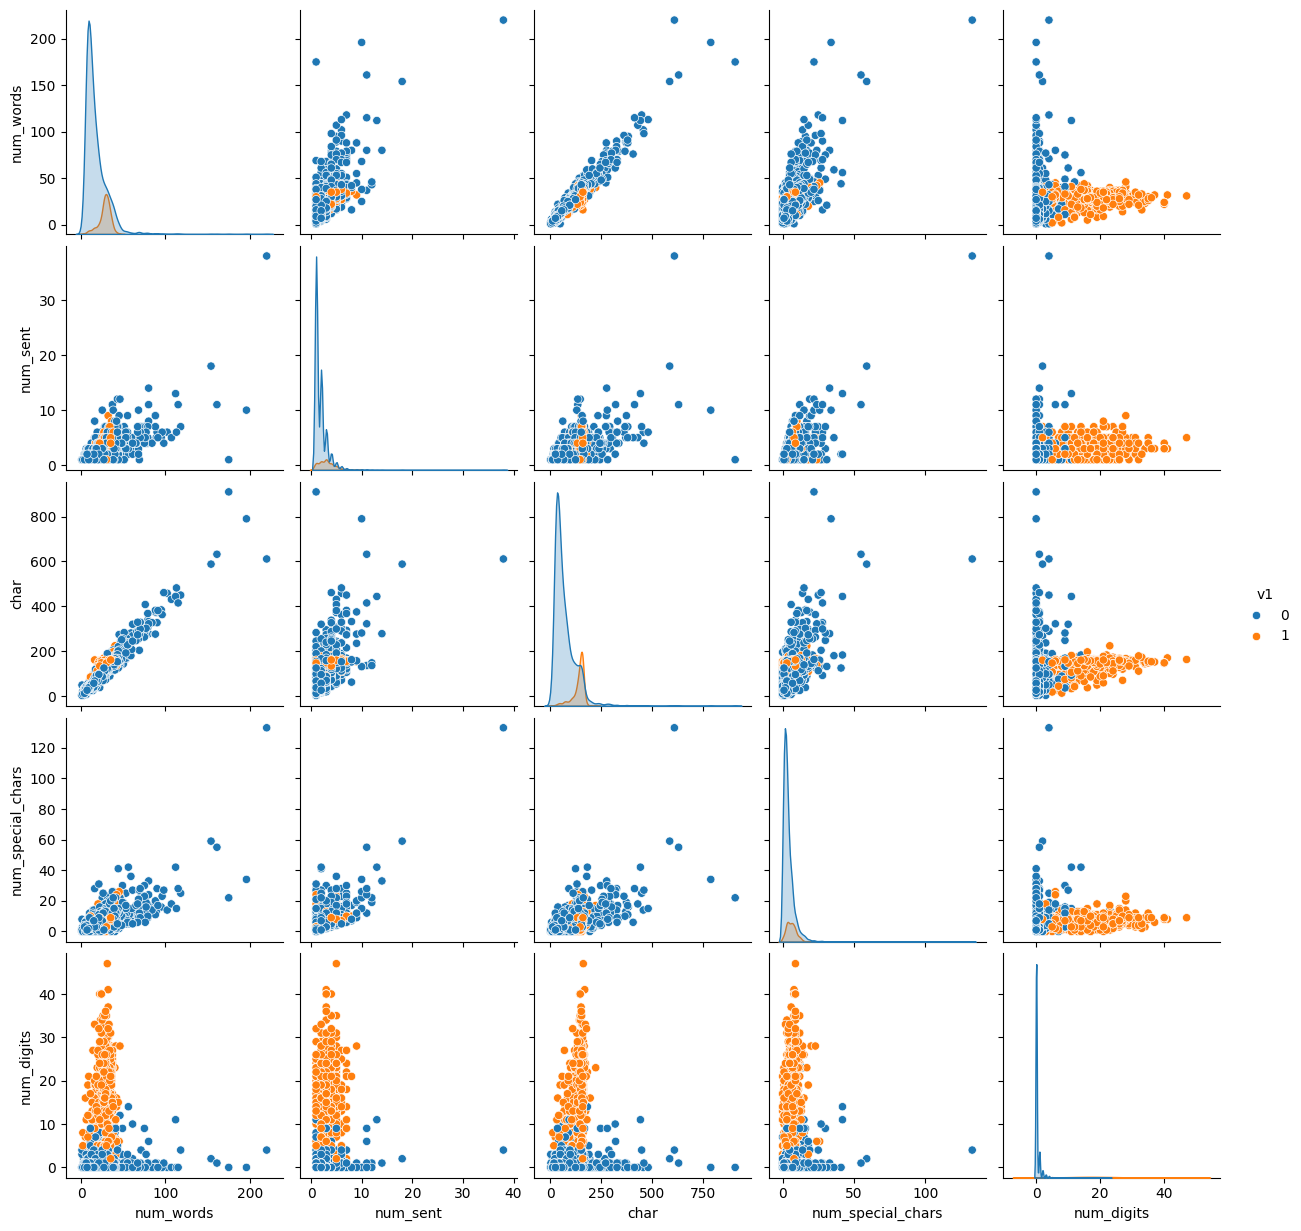

In [83]:
sns.pairplot(
    df[['num_words',	'num_sent'	,'char','num_special_chars','num_digits','v1']],hue='v1'

)
plt.show()

<Axes: >

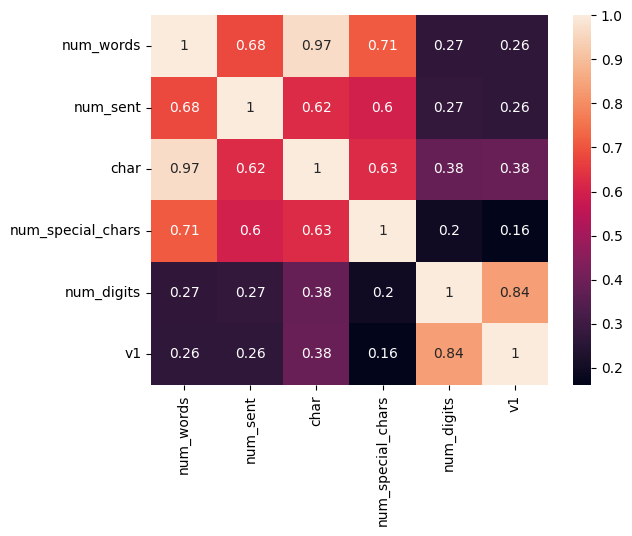

In [84]:
sns.heatmap(df[['num_words',	'num_sent'	,'char','num_special_chars','num_digits','v1']].corr(),annot=True)

number of digits ar eexceptionally high in spam messages

**TEXT** **PREPROCESSING**


*   LOWER CASE



*   CLEANING MORE URLS AND PHONE NUMBER


*   NOT REMOVING SPECIAL CHARACTER THEY CAN COME HANDY





*   REMOVE STOP WORDS AND PUNCTATION



*   TOKENIZATION


*   STEMMING



In [86]:
df.drop(columns=['words','sent'],inplace=True)

In [87]:
df.head()

,v1,v2,num_words,num_sent,char,num_digits,num_special_chars
0,0,"Go until jurong point, crazy.. Available only ...",24,2,111,0,9
1,0,Ok lar... Joking wif u oni...,8,2,29,0,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2,155,25,6
3,0,U dun say so early hor... U c already then say...,13,1,49,0,6
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1,61,0,2


In [88]:
df['v2'] = df['v2'].str.lower()

In [89]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

df['tokens'] = df['v2'].apply(nltk.word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [90]:
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [91]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

df['tokens'] = df['tokens'].apply(
    lambda tokens: [ps.stem(word) for word in tokens]
)

In [92]:
df['clean_text'] = df['tokens'].apply(
    lambda x: ' '.join(x)
)

In [93]:
import re

def clean_text(text):
    text = text.lower()

    # URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)

    # Phone numbers
    text = re.sub(r'\b\d{7,15}\b', ' PHONE ', text)

    # Extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [94]:
df['clean_text'] = df['clean_text'].apply(clean_text)

In [95]:
df.head()

,v1,v2,num_words,num_sent,char,num_digits,num_special_chars,tokens,clean_text
0,0,"go until jurong point, crazy.. available only ...",24,2,111,0,9,"[go, jurong, point, ,, crazi, .., avail, bugi,...","go jurong point , crazi .. avail bugi n great ..."
1,0,ok lar... joking wif u oni...,8,2,29,0,6,"[ok, lar, ..., joke, wif, u, oni, ...]",ok lar ... joke wif u oni ...
2,1,free entry in 2 a wkly comp to win fa cup fina...,37,2,155,25,6,"[free, entri, 2, wkli, comp, win, fa, cup, fin...",free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say so early hor... u c already then say...,13,1,49,0,6,"[u, dun, say, earli, hor, ..., u, c, alreadi, ...",u dun say earli hor ... u c alreadi say ...
4,0,"nah i don't think he goes to usf, he lives aro...",15,1,61,0,2,"[nah, n't, think, goe, usf, ,, live, around, t...","nah n't think goe usf , live around though"


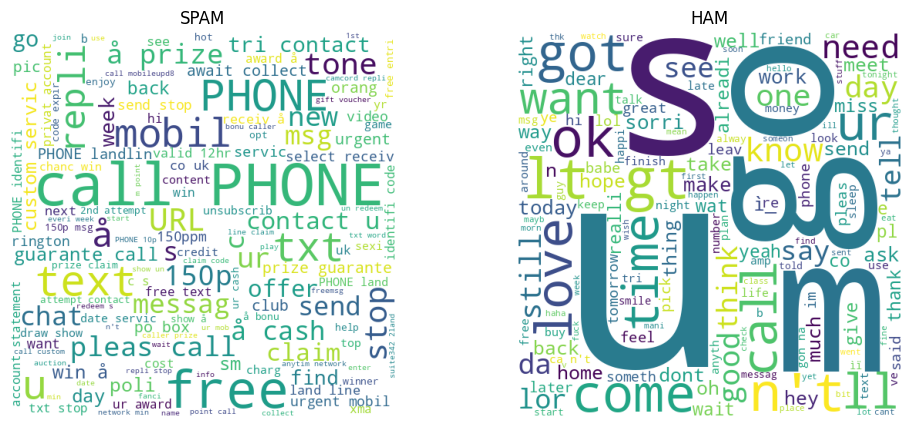

In [99]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_text = df[df['v1'] == 1]['clean_text'].str.cat(sep=' ')
ham_text = df[df['v1'] == 0]['clean_text'].str.cat(sep=' ')

spam_wc = WordCloud(
    width=500,
    height=500,
    min_font_size=10,
    background_color='white'
).generate(spam_text)

ham_wc = WordCloud(
    width=500,
    height=500,
    min_font_size=10,
    background_color='white'
).generate(ham_text)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(spam_wc)
plt.title('SPAM')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ham_wc)
plt.title('HAM')
plt.axis('off')

plt.show()

**MODEL MAKING**

|  | Vectorizer                       | ML Model                | Why                                                     |
| - | -------------------------------- | ----------------------- | ------------------------------------------------------- |
| 1 | **BoW**                          | Logistic Regression     | Simple baseline                                         |
| 2 | **TF-IDF**                       | Logistic Regression     | Strong traditional baseline                           |
| 3 | **TF-IDF**                       | Multinomial Naive Bayes | Very common for text classification                     |
| 4 | **TF-IDF**                       | Linear SVM              | Often very strong for text                              |
| 5 | **TF-IDF + engineered features** | Logistic Regression     | Tests whether your `num_words`, `num_digits`, etc. help |




In [ ]:
# BOW

In [104]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X1 = vectorizer.fit_transform(df['clean_text'])
y = df['v1']

print(X1.toarray())


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X2 = vectorizer.fit_transform(df['clean_text'])


print(X2.toarray())



[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [107]:
from sklearn.model_selection import cross_val_score, KFold
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)



In [105]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression(penalty='l2', C=1.0,
                        tol=0.0001, fit_intercept=True,
                       intercept_scaling=1, class_weight=None,
                       random_state=42, solver='lbfgs', max_iter=1000, verbose=0, warm_start=False, n_jobs=-1)

**BOW ON LOG REG**

In [116]:
cross_val_results = cross_val_score(clf, X1, y, cv=kf)
print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Cross-Validation Results (Accuracy):
  Fold 1: 97.97%
  Fold 2: 97.68%
  Fold 3: 98.45%
  Fold 4: 98.36%
  Fold 5: 98.26%
Mean Accuracy: 98.14%
Accuracy : 0.9796905222437138
Precision: 0.984375
Recall   : 0.8689655172413793
F1 Score : 0.9230769230769231
ROC-AUC  : 0.9966952406811217

Confusion Matrix:
[[887   2]
 [ 19 126]]


**TF IDF ON LOG REG**

In [117]:
cross_val_results = cross_val_score(clf, X2, y, cv=kf)
print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Cross-Validation Results (Accuracy):
  Fold 1: 95.84%
  Fold 2: 95.36%
  Fold 3: 95.45%
  Fold 4: 95.84%
  Fold 5: 95.93%
Mean Accuracy: 95.69%
Accuracy : 0.9584139264990329
Precision: 0.9636363636363636
Recall   : 0.7310344827586207
F1 Score : 0.8313725490196079
ROC-AUC  : 0.9922345913657344

Confusion Matrix:
[[885   4]
 [ 39 106]]


**LOG REG WITH TF IDF AND MULTIPLE FEAURES**

In [120]:
from scipy.sparse import hstack
X_extra = df[
    ['num_words', 'num_sent', 'char',
     'num_special_chars', 'num_digits']
].values

X_final = hstack([X2, X_extra])

In [121]:
cross_val_results = cross_val_score(clf, X2, y, cv=kf)
print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Cross-Validation Results (Accuracy):
  Fold 1: 95.84%
  Fold 2: 95.36%
  Fold 3: 95.45%
  Fold 4: 95.84%
  Fold 5: 95.93%
Mean Accuracy: 95.69%
Accuracy : 0.9787234042553191
Precision: 0.984251968503937
Recall   : 0.8620689655172413
F1 Score : 0.9191176470588235
ROC-AUC  : 0.9902408750630309

Confusion Matrix:
[[887   2]
 [ 20 125]]


**LOG REG WITH MULTIPLE FEATUES AND BOW**

In [122]:
from scipy.sparse import hstack
X_extra = df[
    ['num_words', 'num_sent', 'char',
     'num_special_chars', 'num_digits']
].values

X_final = hstack([X1, X_extra])

In [123]:
cross_val_results = cross_val_score(clf, X2, y, cv=kf)
print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Cross-Validation Results (Accuracy):
  Fold 1: 95.84%
  Fold 2: 95.36%
  Fold 3: 95.45%
  Fold 4: 95.84%
  Fold 5: 95.93%
Mean Accuracy: 95.69%
Accuracy : 0.9845261121856866
Precision: 0.9849624060150376
Recall   : 0.903448275862069
F1 Score : 0.9424460431654677
ROC-AUC  : 0.99491873860595

Confusion Matrix:
[[887   2]
 [ 14 131]]


**SO FAR LOGISTIC REGRESSION WITH MUTIPLE FEATUES AND BOW HAS PERFORMED BETTER THAT OTHERS**